#**E-commerce Customer Analysis**

Identificando padrões de compra e oportunidades de negócio

*   Objetivo:
  *   Analisar o comportamento de compra dos clientes em um e-commerce, identificando padrões, tendências e oportunidades para geração de valor para o negócio.




In [2]:
# Setup e Importação de Bibliotecas

import pandas as pd
import numpy as np
import os
import kagglehub as kh
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

**Análise Exploratória dos dados**


*   **Fonte:** Kaggle
*   **Descrição:** Este dataset reúne dados transacionais de um e-commerce, contemplando informações sobre produtos vendidos e a receita gerada pelos usuários ao longo do tempo. A base possibilita a análise de comportamento dos clientes, padrões de compra e desempenho do negócio, permitindo a extração de insights acionáveis.



In [3]:
# Importação dos Dados (Kaggle)
path = kh.dataset_download("mexwell/google-merchandise-sales-data")

# Listar arquivos disponíveis
files = os.listdir(path)
print("Arquivos disponíveis:", files)

100%|██████████| 4.59M/4.59M [00:00<00:00, 199MB/s]

Extracting files...
Arquivos disponíveis: ['events1.csv', 'users.csv', 'items.csv']


Na seção anterior, realizamos o setup do ambiente e nesta a importação dos dados, garantindo reprodutibilidade por meio do uso da API do Kaggle.


In [4]:
# Carregamento dos Datasets
items_df = pd.read_csv(os.path.join(path, "items.csv"))
users_df = pd.read_csv(os.path.join(path, "users.csv"))
events_df = pd.read_csv(os.path.join(path, "events1.csv"))

In [5]:
# Visão Inicial dos Dados
print(f"items_df: {items_df.shape[0]} linhas | {items_df.shape[1]} colunas")
print(f"users_df: {users_df.shape[0]} linhas | {users_df.shape[1]} colunas")
print(f"events_df: {events_df.shape[0]} linhas | {events_df.shape[1]} colunas")

items_df: 1381 linhas | 6 colunas
users_df: 270154 linhas | 3 colunas
events_df: 758884 linhas | 7 colunas


In [6]:
# Preview do dataset principal
events_df.head()

,user_id,ga_session_id,country,device,type,item_id,date
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44
4,5808,4267,US,mobile,add_to_cart,842,2020-11-01 03:06:29


**Entendimento dos dados no df_Events**

In [7]:
#Entendimento dos dados em events_df
events_df.info()

# Colunas disponíveis
events_df.columns

# Valores únicos em colunas importantes
events_df['type'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758884 entries, 0 to 758883
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        758884 non-null  int64 
 1   ga_session_id  758884 non-null  int64 
 2   country        754329 non-null  object
 3   device         758884 non-null  object
 4   type           758884 non-null  object
 5   item_id        758884 non-null  int64 
 6   date           758884 non-null  object
dtypes: int64(3), object(4)
memory usage: 40.5+ MB


,count
type,
add_to_cart,667282
begin_checkout,76047
purchase,15555


In [8]:
# Quantidade de usuários e produtos únicos em Events
print("Usuários únicos:", events_df['user_id'].nunique())
print("Produtos únicos:", events_df['item_id'].nunique())

Usuários únicos: 14701
Produtos únicos: 1381


**Interpretação inicial**

O dataset `events_df` representa eventos de interação dos usuários com o e-commerce.

Cada linha corresponde a uma ação realizada por um usuário, como visualização ou compra de um produto.

A variável `event_type` indica o tipo de interação, enquanto `user_id` e `item_id` permitem identificar os usuários e produtos envolvidos.

Esses dados possibilitam analisar o comportamento do usuário ao longo do tempo, incluindo padrões de navegação e conversão.

In [9]:
# Entendimento dos Dados - items_df

# Estrutura geral
items_df.info()

# Colunas disponíveis
items_df.columns

# Visualização inicial
items_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1381 non-null   int64 
 1   name          1381 non-null   object
 2   brand         1381 non-null   object
 3   variant       973 non-null    object
 4   category      1381 non-null   object
 5   price_in_usd  1381 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 64.9+ KB


,id,name,brand,variant,category,price_in_usd
0,0,Google Land & Sea Cotton Cap,Google,Single Option Only,Apparel,14
1,1,Google KeepCup,Google,Single Option Only,New,28
2,2,Google Land & Sea Nalgene Water Bottle,Google,Single Option Only,Drinkware,20
3,3,Google Unisex Eco Tee Black,Google,LG,Uncategorized Items,22
4,4,Google Chicago Campus Bottle,Google,Single Option Only,Campus Collection,11


In [10]:
# Ver distribuição de categorias
items_df['category'].value_counts().head(10)

,count
category,
Apparel,582
Campus Collection,198
Clearance,123
New,86
Accessories,82
Uncategorized Items,56
Shop by Brand,55
Bags,48
Office,34


**Interpretação - items_df**

O dataset `items_df` contém informações sobre os produtos disponíveis no e-commerce.

Esses dados serão utilizados para enriquecer o dataset de eventos (`events_df`), permitindo análises mais detalhadas por categoria e características dos produtos.

In [11]:
events_df['item_id'] = events_df['item_id'].astype(int)
items_df['id'] = items_df['id'].astype(int)

# Verificar tipos
print(events_df['item_id'].dtype)
print(items_df['id'].dtype)

int64
int64


In [12]:
#Verificar nulos
events_df['item_id'].isnull().sum()
items_df['id'].isnull().sum()

np.int64(0)

In [13]:
# Ver duplicados na dimensão
items_df['id'].duplicated().sum()

np.int64(0)

Merge dos Datasets (Events + Items)

In [14]:
# Merge dos Datasets (events + items)
df = events_df.merge(items_df, left_on='item_id', right_on='id', how='left')
df = df.drop(columns=['id']) #Remover duplicadas de ID
df = df.rename(columns={'type': 'event_type'}) #Renomear coluna de ID
print("Dimensão após merge:", df.shape)

Dimensão após merge: (758884, 12)


In [15]:
# Conferir resultado
df.head()

,user_id,ga_session_id,country,device,event_type,item_id,date,name,brand,variant,category,price_in_usd
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14,Google Large Tote White,Google,Single Option Only,Bags,10
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14,Google Heather Green Speckled Tee,Google,XL,Apparel,21
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44,Google KeepCup,Google,Single Option Only,New,28
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44,Google Mini Kick Ball,Google,Single Option Only,Fun,2
4,5808,4267,US,mobile,add_to_cart,842,2020-11-01 03:06:29,Google Infant Hero Onesie Grey,Google,NaN,Apparel,25


**Limpeza e preparação de dados**

In [16]:
# Limpeza e Preparação dos Dados

# Converter data
df['date'] = pd.to_datetime(df['date'])

# Ver valores nulos
df.isnull().sum().sort_values(ascending=False)

,0
variant,636260
country,4555
ga_session_id,0
user_id,0
device,0
event_type,0
date,0
item_id,0
name,0
brand,0


In [17]:
# Ver distribuição dos eventos
df['event_type'].value_counts()

,count
event_type,
add_to_cart,667282
begin_checkout,76047
purchase,15555


In [18]:
# Ver valores de preço
df['price_in_usd'].describe()

,price_in_usd
count,758884.000000
mean,24.759137
std,20.892459
min,1.000000
25%,11.000000
50%,22.000000
75%,30.000000
max,313.000000


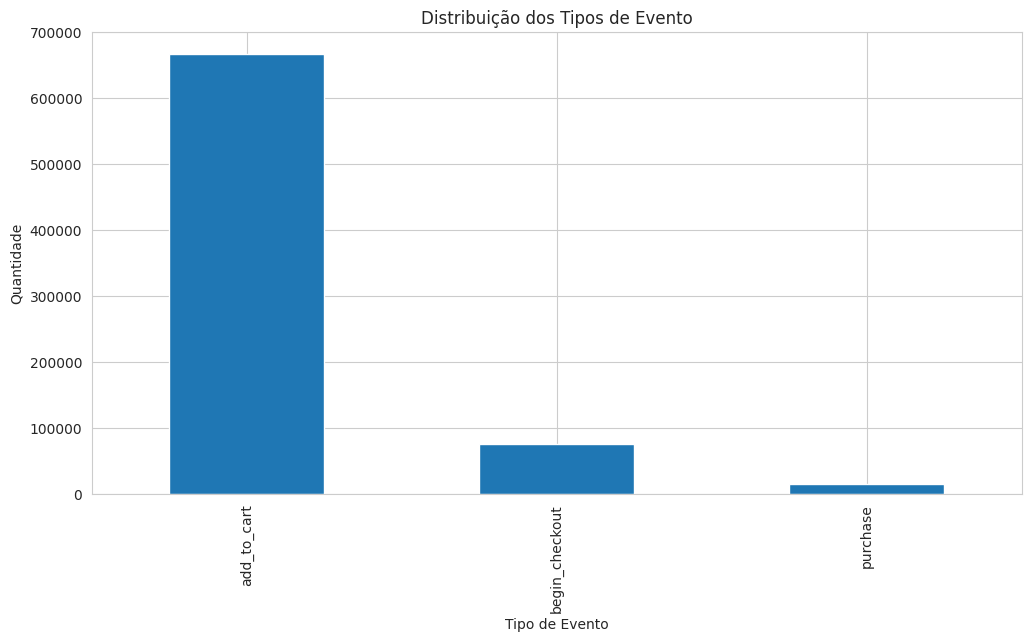

In [19]:
#Distribuição dos Eventos

df['event_type'].value_counts().plot(kind='bar')
plt.title('Distribuição dos Tipos de Evento')
plt.xlabel('Tipo de Evento')
plt.ylabel('Quantidade')
plt.show()

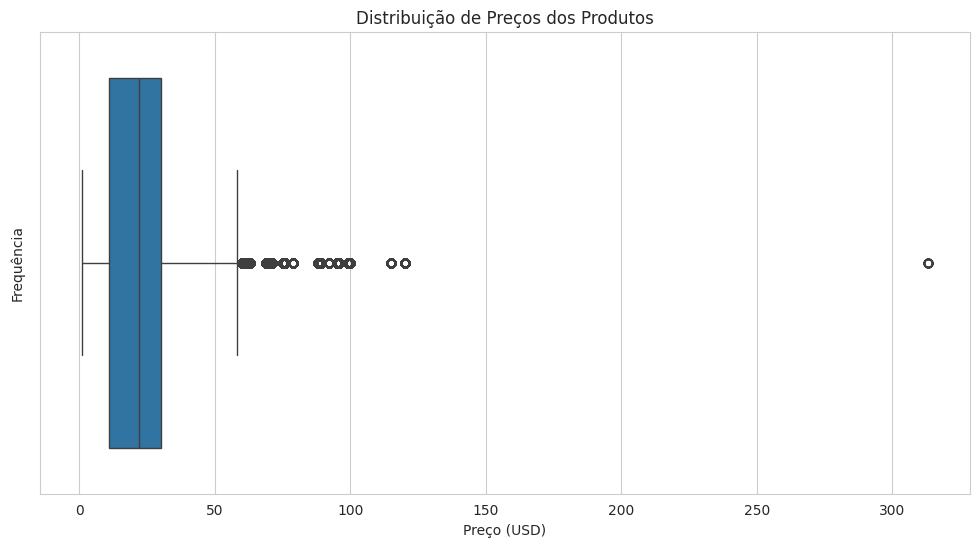

In [50]:
#Distribuição de Preços

sns.histplot(df['price_in_usd'], bins=50)
plt.title('Distribuição de Preços dos Produtos')
plt.xlabel('Preço (USD)')
plt.ylabel('Frequência')
plt.show()

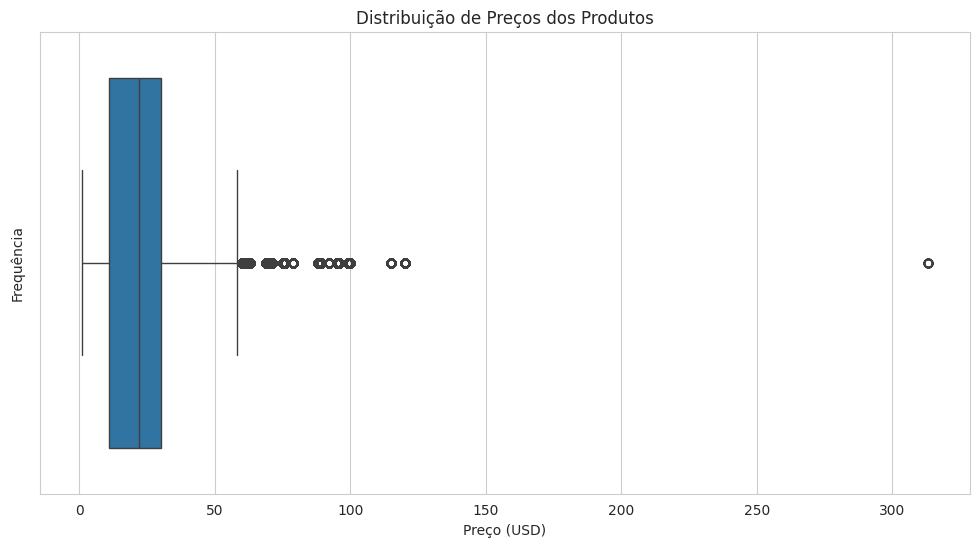

In [52]:
sns.boxplot(x=df['price_in_usd'])
plt.title('Distribuição de Preços dos Produtos')
plt.xlabel('Preço (USD)')
plt.ylabel('Frequência')
plt.show()

**Insight inicial**

Observa-se que a maior parte das interações dos usuários está concentrada na etapa de adição ao carrinho, com baixa conversão para compras.

Além disso, a distribuição de preços apresenta alta variabilidade, o que pode influenciar o comportamento de compra dos usuários.

**Feature Engineering**

In [21]:
#Filtrar apenas compras

purchases_df = df[df['event_type'] == 'purchase'].copy()

print("Quantidade de compras:", purchases_df.shape[0])

Quantidade de compras: 15555


In [22]:
#Receita Total

total_revenue = purchases_df['price_in_usd'].sum()

print(f"Receita total: ${total_revenue:,.2f}")

Receita total: $307,114.00


In [23]:
#Ticket Médio

avg_ticket = purchases_df['price_in_usd'].mean()

print(f"Ticket médio: ${avg_ticket:.2f}")

Ticket médio: $19.74


In [24]:
#Pedidos por Cliente

orders_per_user = purchases_df.groupby('user_id').size()

orders_per_user.describe()

,0
count,4066.000000
mean,3.825627
std,3.868228
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,60.000000


In [25]:
#Clientes Recorrentes

recurring_users = (orders_per_user > 1).sum()
one_time_users = (orders_per_user == 1).sum()

total_users = orders_per_user.shape[0]

print(f"Clientes recorrentes: {recurring_users} ({(recurring_users/total_users)*100:.2f}%)")
print(f"Clientes de uma compra: {one_time_users} ({(one_time_users/total_users)*100:.2f}%)")

Clientes recorrentes: 3006 (73.93%)
Clientes de uma compra: 1060 (26.07%)


In [26]:
#Receita por Categoria

revenue_by_category = purchases_df.groupby('category')['price_in_usd'].sum().sort_values(ascending=False)

revenue_by_category.head(10)

,price_in_usd
category,
Apparel,167316
Bags,19707
New,19179
Campus Collection,16260
Shop by Brand,15473
Accessories,14637
Drinkware,11008
Uncategorized Items,10967
Lifestyle,10366


**Métricas de Negócio**
Foram criadas métricas fundamentais para entender o desempenho do e-commerce, incluindo receita total com valor de 307 mil, ticket médio de 19 doláres e comportamento de compra dos clientes.

Essas métricas permitem uma análise mais aprofundada do valor gerado e da retenção de clientes.

**Funil de conversão**

In [ ]:
#Funil de Conversão
event_counts = df['event_type'].value_counts()

add_to_cart = event_counts.get('add_to_cart', 0)
purchase = event_counts.get('purchase', 0)

conversion_rate = (purchase / add_to_cart) * 100

print(f"Add to Cart: {add_to_cart}")
print(f"Purchases: {purchase}")
print(f"Taxa de Conversão: {conversion_rate:.2f}%")

Add to Cart: 667282
Purchases: 15555
Taxa de Conversão: 2.33%


A taxa de conversão entre adição ao carrinho e compra é de 2.33%, indicando uma perda significativa ao longo do funil.

In [54]:
# Contagem de eventos
funnel = df['event_type'].value_counts().loc[['add_to_cart', 'begin_checkout', 'purchase']]

funnel

,count
event_type,
add_to_cart,667282
begin_checkout,76047
purchase,15555


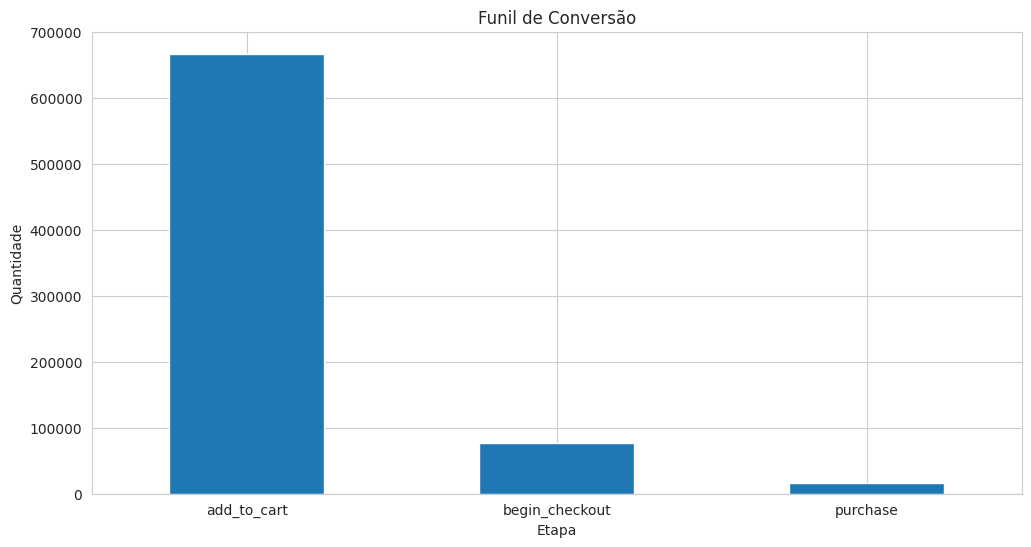

In [57]:
funnel.plot(kind='bar')

plt.title('Funil de Conversão')
plt.xlabel('Etapa')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

**Análise do Funil de Conversão**

Observa-se que há um volume significativamente maior de eventos de "add_to_cart" em comparação com "purchase".

A queda ao longo das etapas do funil sugere possíveis pontos de fricção na jornada do usuário, especialmente entre a adição ao carrinho e a finalização da compra, porém
os dados não garantem a sequência de eventos por usuário, os resultados devem ser interpretados como uma visão agregada do comportamento, e não como um funil estrito de conversão.

In [61]:
#Construção do Funil por Sessão
session_funnel = df.groupby(['ga_session_id', 'event_type']).size().unstack(fill_value=0)
session_funnel.head()

event_type,add_to_cart,begin_checkout,purchase
ga_session_id,,,
0,888,78,13
1,876,78,6
2,888,30,0
3,828,57,19
4,612,204,22


In [62]:
# Converter para flags (0 ou 1)
session_funnel = (session_funnel > 0).astype(int)

session_funnel.head()

event_type,add_to_cart,begin_checkout,purchase
ga_session_id,,,
0,1,1,1
1,1,1,1
2,1,1,0
3,1,1,1
4,1,1,1


In [63]:
for col in ['add_to_cart', 'begin_checkout', 'purchase']:
    if col not in session_funnel.columns:
        session_funnel[col] = 0

In [64]:
add_to_cart_sessions = session_funnel['add_to_cart'].sum()

checkout_sessions = session_funnel[
    (session_funnel['add_to_cart'] == 1) &
    (session_funnel['begin_checkout'] == 1)
].shape[0]

purchase_sessions = session_funnel[
    (session_funnel['add_to_cart'] == 1) &
    (session_funnel['purchase'] == 1)
].shape[0]

print("Sessões com add_to_cart:", add_to_cart_sessions)
print("Sessões com checkout:", checkout_sessions)
print("Sessões com purchase:", purchase_sessions)

Sessões com add_to_cart: 15132
Sessões com checkout: 5312
Sessões com purchase: 2573


In [65]:
checkout_rate = (checkout_sessions / add_to_cart_sessions) * 100
purchase_rate = (purchase_sessions / add_to_cart_sessions) * 100

print(f"Conversão para checkout: {checkout_rate:.2f}%")
print(f"Conversão para compra: {purchase_rate:.2f}%")

Conversão para checkout: 35.10%
Conversão para compra: 17.00%


In [66]:
import plotly.graph_objects as go

funnel_labels = ['Add to Cart', 'Begin Checkout', 'Purchase']
funnel_values = [add_to_cart_sessions, checkout_sessions, purchase_sessions]

fig = go.Figure(go.Funnel(
    y=funnel_labels,
    x=funnel_values,
    textinfo="value+percent initial"
))

fig.update_layout(title="Funil de Conversão por Sessão")

fig.show()

**Funil de Conversão por Sessão**

A análise por sessão permite uma visão mais precisa do comportamento do usuário ao longo da jornada de compra.

Observa-se que nem todas as sessões que adicionam itens ao carrinho avançam para as etapas seguintes, indicando possíveis pontos de fricção no processo de conversão.

A taxa de conversão entre as etapas evidencia oportunidades de otimização na experiência do usuário. Com conversão para checkout de 35% e de compra de 17%.

**Análise Temporal**

In [27]:
#Receita ao longo do tempo

revenue_over_time = purchases_df.groupby(purchases_df['date'].dt.date)['price_in_usd'].sum()

revenue_over_time.head()

,price_in_usd
date,
2020-11-01,648
2020-11-02,3553
2020-11-03,2874
2020-11-04,2010
2020-11-05,1433


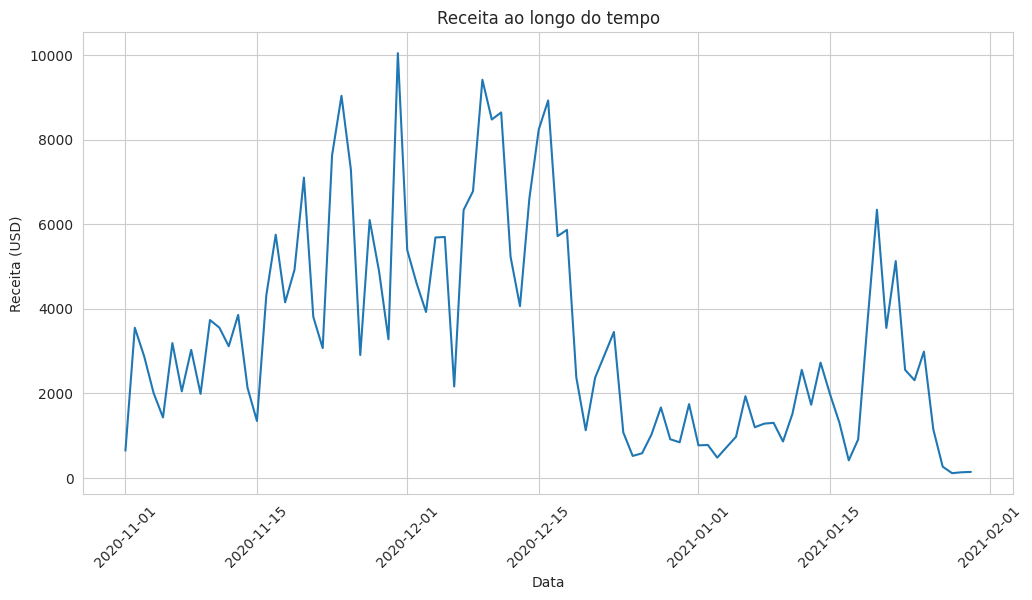

In [28]:
revenue_over_time.plot()

plt.title('Receita ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Receita (USD)')
plt.xticks(rotation=45)
plt.show()

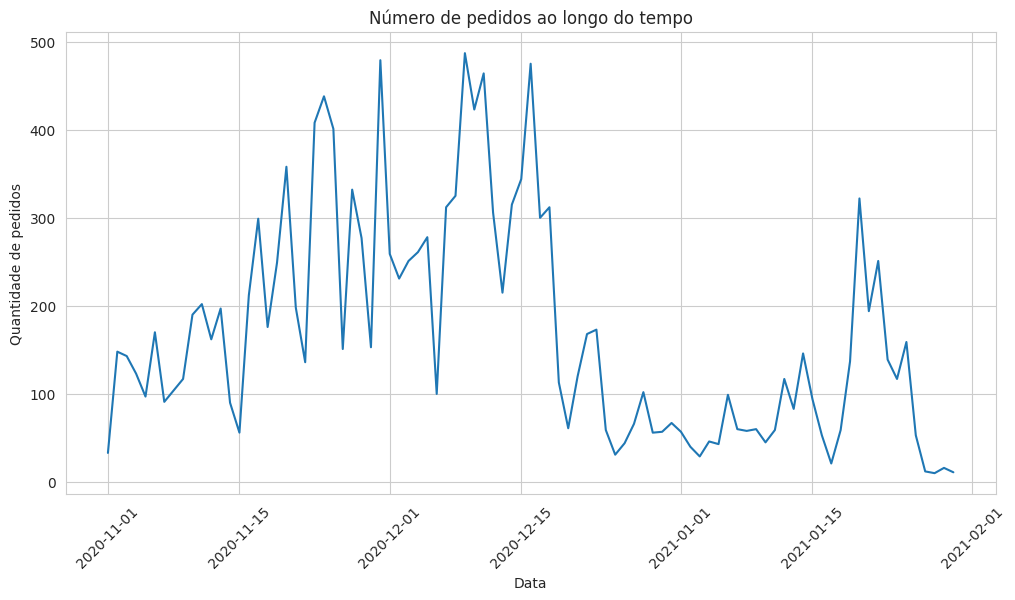

In [29]:
orders_over_time = purchases_df.groupby(purchases_df['date'].dt.date).size()

orders_over_time.plot()

plt.title('Número de pedidos ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Quantidade de pedidos')
plt.xticks(rotation=45)
plt.show()

In [30]:
df['date'].dt.month.value_counts().sort_index()

,count
date,
1,200610
11,99418
12,458856


**Insight - Análise Temporal**

Observa-se um aumento significativo no número de pedidos entre meados de novembro e um crescimento maior em dezembro com cerca de 458.856 compras.

Esse comportamento pode estar associado a períodos promocionais e datas comemorativas, como Black Friday e o período de compras de fim de ano, que tendem a impulsionar o consumo no e-commerce.

Após esse período, nota-se uma queda no volume de pedidos, indicando um possível efeito sazonal, seguido de uma subida na metade de janeiro.

**Análise de clientes**

In [32]:
#Top clientes por receita
top_customers = purchases_df.groupby('user_id')['price_in_usd'].sum().sort_values(ascending=False)

top_customers.head(10)

,price_in_usd
user_id,
7765,1410
27893,1200
11073,933
15696,864
20451,857
1298,818
28943,781
1569,752
22119,640


In [33]:
#Frequência de compra
orders_per_user.describe()

,0
count,4066.000000
mean,3.825627
std,3.868228
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,60.000000


**Análise de produtos**

In [34]:
#Produtos mais vendidos

top_products = purchases_df['name'].value_counts().head(10)

top_products

,count
name,
Super G Unisex Joggers,285
Google Zip Hoodie F/C,256
Google Crewneck Sweatshirt Navy,225
Google Camp Mug Ivory,223
Google Heathered Pom Beanie,194
Google Badge Heavyweight Pullover Black,184
Google Crewneck Sweatshirt Green,177
Google F/C Longsleeve Charcoal,164
Google Red Speckled Tee,160


In [35]:
#Produtos com maior receita

top_revenue_products = purchases_df.groupby('name')['price_in_usd'].sum().sort_values(ascending=False).head(10)

top_revenue_products

,price_in_usd
name,
Google Zip Hoodie F/C,12792
Google Crewneck Sweatshirt Navy,9900
Google Men's Tech Fleece Grey,9489
Super G Unisex Joggers,9068
Google Badge Heavyweight Pullover Black,8464
Google Crewneck Sweatshirt Green,7788
Google Men's Puff Jacket Black,5911
Google Sherpa Zip Hoodie Charcoal,5775
Google Women's Puff Jacket Black,5750


In [36]:
#Ticket médio por categoria

avg_ticket_category = purchases_df.groupby('category')['price_in_usd'].mean().sort_values(ascending=False)

avg_ticket_category

,price_in_usd
category,
Black Lives Matter,52.000000
Gift Cards,42.372881
Apparel,32.300386
Bags,28.355396
Uncategorized Items,21.846614
Eco-Friendly,19.000000
Shop by Brand,18.420238
Lifestyle,16.855285
Drinkware,15.374302


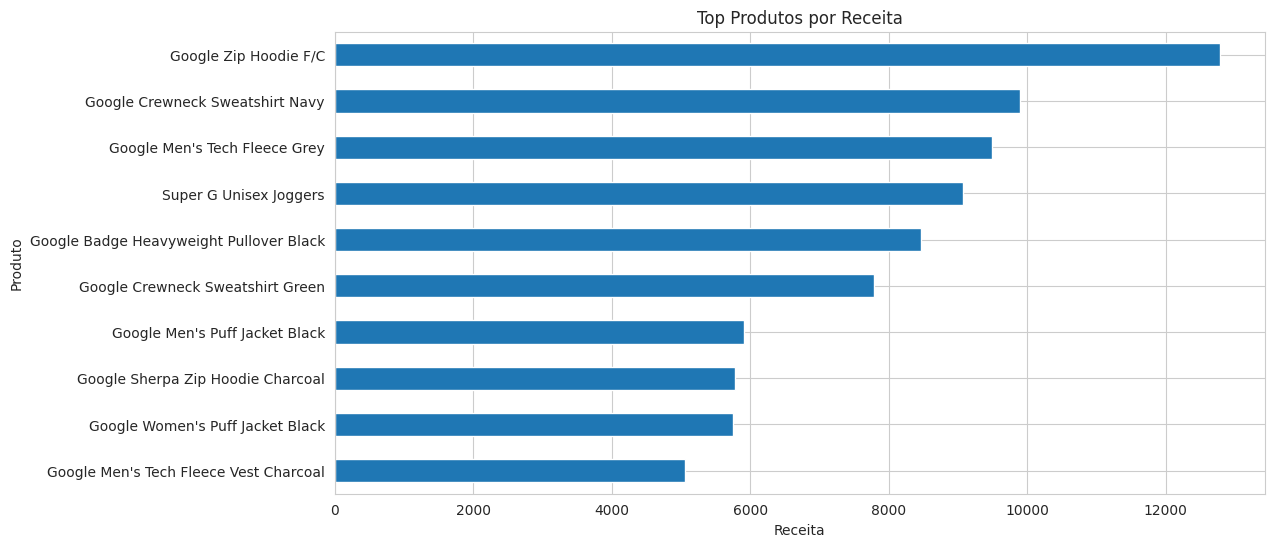

In [37]:
top_revenue_products.head(10).plot(kind='barh')

plt.title('Top Produtos por Receita')
plt.xlabel('Receita')
plt.ylabel('Produto')
plt.gca().invert_yaxis()
plt.show()

**Funil por categoria**

In [39]:
#Funil por Categoria (Sessão)

category_session = df.groupby(['category', 'ga_session_id', 'event_type']).size().unstack(fill_value=0)
category_session = (category_session > 0).astype(int)
for col in ['add_to_cart', 'begin_checkout', 'purchase']:
    if col not in category_session.columns:
        category_session[col] = 0
category_funnel = category_session.groupby('category').agg({
    'add_to_cart': 'sum',
    'begin_checkout': 'sum',
    'purchase': 'sum'
})

category_funnel['conversion_rate'] = (
    category_funnel['purchase'] / category_funnel['add_to_cart']
) * 100

category_funnel = category_funnel.sort_values(by='conversion_rate', ascending=False)

category_funnel.head(10)

event_type,add_to_cart,begin_checkout,purchase,conversion_rate
category,,,,
Gift Cards,14,19,11,78.571429
Black Lives Matter,3,1,2,66.666667
Campus Collection,2146,900,768,35.787512
Apparel,11956,4262,2690,22.499164
Office,3222,751,571,17.721912
Small Goods,1631,298,258,15.818516
Bags,3500,783,505,14.428571
Writing Instruments,935,168,133,14.224599
Accessories,5983,989,777,12.986796


**Conversão por Categoria**

A análise do funil por categoria revela diferenças significativas no comportamento de compra.

Categorias como *Gift Cards* e *Black Lives Matter* apresentam taxas de conversão extremamente elevadas (>60%), indicando alta intenção de compra, embora com baixo volume de interações.

A *Campus Collection* se destaca como a categoria mais equilibrada, combinando volume relevante com alta taxa de conversão (~35%), representando uma oportunidade estratégica de crescimento.

Por outro lado, categorias como *Accessories*, *Drinkware* e *Bags* apresentam alto volume de interações, mas baixa conversão (~12–14%), sugerindo possíveis pontos de fricção na jornada de compra, como preço, usabilidade ou experiência.

Esses padrões indicam oportunidades tanto de otimização de conversão quanto de priorização de categorias com maior potencial de receita.

**Segmentação de clientes**

In [40]:
#Construção da base RFM

rfm = purchases_df.groupby('user_id').agg({
    'date': 'max',              # última compra
    'user_id': 'count',         # frequência
    'price_in_usd': 'sum'       # valor total
})

rfm.columns = ['last_purchase', 'frequency', 'monetary']

rfm.head()

,last_purchase,frequency,monetary
user_id,,,
3,2020-11-25 03:56:58,3,184
4,2020-11-30 16:11:21,9,89
6,2020-12-13 21:37:07,3,68
7,2020-12-03 22:03:52,5,56
9,2020-11-30 23:04:25,2,41


In [41]:
# Data de referência (última data do dataset por cliente)
reference_date = purchases_df['date'].max()

rfm['recency'] = (reference_date - rfm['last_purchase']).dt.days

rfm.head()

,last_purchase,frequency,monetary,recency
user_id,,,,
3,2020-11-25 03:56:58,3,184,66
4,2020-11-30 16:11:21,9,89,61
6,2020-12-13 21:37:07,3,68,48
7,2020-12-03 22:03:52,5,56,57
9,2020-11-30 23:04:25,2,41,60


In [46]:
#Scoring RFM (robusto)

rfm['R_score'] = pd.qcut(rfm['recency'].rank(method='first'), 4, labels=[4,3,2,1])

rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])

rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 4, labels=[1,2,3,4])

In [47]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_score
user_id,,,,,,,,
3,2020-11-25 03:56:58,3,184,66,2,2,4,224
4,2020-11-30 16:11:21,9,89,61,2,4,3,243
6,2020-12-13 21:37:07,3,68,48,3,2,3,323
7,2020-12-03 22:03:52,5,56,57,2,3,3,233
9,2020-11-30 23:04:25,2,41,60,2,2,2,222


In [48]:
#Segmentação de Clientes
def segment(row):
    if row['RFM_score'] == '444':
        return 'Melhores Clientes'
    elif row['F_score'] == 4:
        return 'Frequentes'
    elif row['M_score'] == 4:
        return 'Alto Valor'
    elif row['R_score'] == 4:
        return 'Recentes'
    else:
        return 'Outros'

rfm['segment'] = rfm.apply(segment, axis=1)

rfm['segment'].value_counts()

,count
segment,
Outros,1977
Frequentes,892
Recentes,696
Alto Valor,376
Melhores Clientes,125


In [68]:
import plotly.express as px

segment_counts = rfm['segment'].value_counts().reset_index()
segment_counts.columns = ['segment', 'count']

fig = px.treemap(
    segment_counts,
    path=['segment'],
    values='count',
    title='Distribuição de Segmentos de Clientes (RFM)'
)

fig.show()

A base apresenta forte desigualdade de valor: poucos clientes concentram alto valor (Melhores Clientes e Alto Valor), enquanto a maioria está em segmentos genéricos ou pouco explorados. Isso indica oportunidade de maturação do CRM, com foco em:

- Reativação de clientes recentes
- Conversão de frequentes em alto valor
- Melhor definição do grupo “Outros” para segmentação mais acionável

#**Insights**

**Base de clientes ainda concentrada em baixa maturidade de segmentação**

A análise RFM mostra que a maior parte da base está concentrada no segmento “Outros” (1977 clientes), indicando que grande parte dos usuários não apresenta padrões consistentes de recência, frequência ou valor. No contexto de e-commerce, isso sugere uma base com forte presença de compradores ocasionais ou pouco engajados.
A empresa ainda não possui uma base altamente fidelizada, o que indica dependência de aquisição contínua de novos clientes.

**Pequena parcela de clientes concentra maior valor e deve ser protegida**

Os segmentos de maior valor representam uma fração reduzida da base, mas são estratégicos para o negócio.
Isso indica uma estrutura de receita concentrada em poucos clientes de alto valor, reforçando a importância de estratégias de retenção e relacionamento para evitar perda desse grupo.

**Forte dependência de sazonalidade nas vendas do e-commerce**

O volume de pedidos apresenta picos claros em períodos específicos, especialmente entre novembro e dezembro, seguidos por queda acentuada no início do ano.
Esse padrão indica forte influência de eventos sazonais (ex: Black Friday e Natal), sugerindo necessidade de estratégias para estabilizar receita fora desses períodos.

**Fricção significativa no funil de conversão, especialmente entre carrinho e compra**

Embora haja alto volume de usuários adicionando produtos ao carrinho, a conversão final para compra é baixa, com queda expressiva entre as etapas do funil. Isso indica possíveis barreiras no checkout, como custo final, experiência do usuário ou falta de incentivos à finalização da compra.

**Oportunidade clara de crescimento via clientes frequentes e aumento de ticket médio**

O grupo de clientes frequentes representa uma base relevante e já engajada, mas ainda não totalmente convertida em clientes de alto valor. Esse segmento representa a maior oportunidade de crescimento orgânico, por meio de estratégias de upsell, cross-sell e aumento de recorrência.

Os resultados indicam que o e-commerce possui boa base operacional, mas ainda apresenta oportunidades relevantes em três frentes principais: retenção de clientes de alto valor, melhoria de conversão no funil e redução da dependência de sazonalidade.

## Relatorio Final Automatizado

Nesta etapa final, consolidamos as principais metricas do projeto em um relatorio executivo em Markdown, pronto para apoiar a apresentacao do case no GitHub.


In [ ]:
from report_builder import build_final_report, save_final_report

segment_counts_map = rfm['segment'].value_counts()

report_metrics = {
    'total_revenue': float(total_revenue),
    'avg_ticket': float(avg_ticket),
    'total_customers': int(total_users),
    'recurring_users': int(recurring_users),
    'recurring_share': float((recurring_users / total_users) * 100),
    'cart_to_purchase_rate': float(conversion_rate),
    'session_checkout_rate': float(checkout_rate),
    'session_purchase_rate': float(purchase_rate),
    'top_category': str(revenue_by_category.idxmax()),
    'top_category_revenue': float(revenue_by_category.iloc[0]),
    'top_product': str(top_revenue_products.index[0]),
    'top_product_revenue': float(top_revenue_products.iloc[0]),
    'top_segment': str(segment_counts_map.idxmax()),
    'top_segment_count': int(segment_counts_map.iloc[0]),
    'peak_revenue_day': revenue_over_time.idxmax(),
    'peak_revenue_value': float(revenue_over_time.max()),
}

final_report = build_final_report(report_metrics)
output_path = save_final_report(final_report)

print(final_report)
print(f"\nRelatorio salvo em: {output_path}")


O relatorio gerado resume os resultados de negocio e pode ser utilizado como complemento do portfolio, documentacao do projeto ou material de apresentacao executiva.
